#**<font color = "red"> Bank Marketing Dataset </font>**

---



**What is this dataset about?**

* It contains data from a Portuguese bank’s phone marketing campaign.
* The goal was to determine whether a client would subscribe to a term deposit.






**Why did we select this dataset?**

* It is a real, well-structured dataset with 45,000+ records, perfect for practising binary classification and testing machine learning models.

**What are we predicting?**

* Whether a client will subscribe to a term deposit (target variable y: “yes” or “no”).

--------------------------------------------------------------------------------

1. Import required libraries.

In [ ]:
# ============================================================
#  IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine learning libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

---

<font color = "purple"> We use two versions of the dataset because: </font>

1. The full dataset (45,000+ rows) is used for training machine learning models, since it provides more information and leads to better model performance.

2. The 10% sample dataset is used for quicker testing and visualisation.
This smaller dataset loads faster, plots instantly, and allows us to try out transformations without waiting for heavy processing on the full dataset. </font>

2. Load the dataset.

In [ ]:
# ============================================================
# Load data and set unknown to NaN
# ============================================================

df = pd.read_csv('/content/bank-full.csv', sep=';')
df.replace("unknown", np.nan, inplace=True)

df_small = pd.read_csv('/content/bank.csv', sep=';') # 10 percent dataset
df_small.replace("unknown", np.nan, inplace=True)

#display first five rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


<font color = "#FF3B30"> We manually checked the dataset and found that some missing values were labelled as ‘unknown’, so we converted them to NaN so that Python can correctly recognise and handle them as missing data. </font>

---

# <font color = "green"> **Basic Data Exploration & Cleaning** </font> (Kerim)

3. Basic info of the data.

In [ ]:
# ============================================================
# Get BASIC INFO about the data
# ============================================================

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        44923 non-null  object
 2   marital    45211 non-null  object
 3   education  43354 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    32191 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   8252 non-null   object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None


4. Get statistical information of the dataset.

In [ ]:
print(df.describe())

                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       -1.000000      0.

In [ ]:
df['contact'].value_counts()

,count
contact,
cellular,29285
telephone,2906


In [ ]:
df.head()
df['contact'].unique()

array([nan, 'cellular', 'telephone'], dtype=object)

In [ ]:
# ============================================================
# Check for nulls
# ============================================================

df.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


1. The dataset has 45,211 rows and 17 columns, with a mix of numeric and categorical features, including the target variable y.
2. Some features (job, education, contact, poutcome) have missing values after replacing "unknown" with NaN, which will need handling before modeling.
3. Numeric features like balance, duration, and pdays show wide ranges and potential outliers, helping us plan preprocessing and scaling for machine learning.


---

In [ ]:
# ============================================================
# Find those with more than 30% of null
# ============================================================

missing_pct = round(df.isnull().sum()/len(df) * 100, 1)
print(missing_pct)

age           0.0
job           0.6
marital       0.0
education     4.1
default       0.0
balance       0.0
housing       0.0
loan          0.0
contact      28.8
day           0.0
month         0.0
duration      0.0
campaign      0.0
pdays         0.0
previous      0.0
poutcome     81.7
y             0.0
dtype: float64


**Observation:** 4.1% of the education column has missing values, 28.8% of the contact column has missing values, and 81.7% of the poutcome column has missing values.

**Missing values strategy:** Missing values can significantly impact the reliability and performance of machine learning models. Therefore, the poutcome column should be dropped due to it having more than 30% missing values, and the missing values for the contact, job, and education columns should be filled with the value that appears most frequently in the column.

In [ ]:
# ============================================================
# Drop those with more than 30% of null (both full and 10% dataset)
# ============================================================

drop_cols = missing_pct[missing_pct > 30].index

df_new = df.drop(columns=drop_cols)
df_new_small = df_small.drop(columns='poutcome')

<font color = "#FF3B30"> Columns with more than 30% missing data (like poutcome) are removed because too many missing values can bias the model or reduce predictive power. </font>

---

In [ ]:
# ============================================================
# Check again
# ============================================================

df_new.isnull().sum()

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


In [ ]:
# ============================================================
# Fill in unknown values
# ============================================================

df_new['job'] = df_new['job'].fillna(df_new['job'].mode()[0])
df_new['education'] = df_new['education'].fillna(df_new['education'].mode()[0])
df_new['contact'] = df_new['contact'].fillna(df_new['contact'].mode()[0])
df_new.isnull().sum()

df_new_small['job'].fillna(df_new_small['job'].mode()[0], inplace=True)
df_new_small['education'].fillna(df_new_small['education'].mode()[0], inplace=True)
df_new_small['contact'].fillna(df_new_small['contact'].mode()[0], inplace=True)

<font color = "#FF3B30"> Filled missing values in categorical columns (job, education, contact) with the most frequent value (mode) instead of dropping them, to retain important predictive information while preparing the dataset for modeling.
</font>


---

# <font color = "green"> **Exploratory Data Analysis (EDA) and Visualisations** (Dan / Kerim/ Simran/ Snehdeep)

Visualising numeric features to detect outliers and understand their distributions before modeling.

99th percentile of Age: 71.0


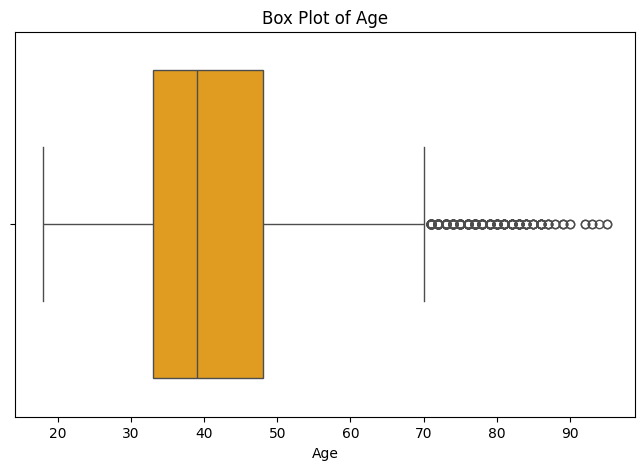

In [ ]:
# ============================================================
# Outlier Detection: Age
# ============================================================

# Calculate 99th percentile to identify extreme values
age_99 = df_new['age'].quantile(0.99)
print(f"99th percentile of Age: {age_99}")

# Boxplot to visualise outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_new['age'], color='orange')
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

**Observation:** Most ages are below 80, a few extreme values exist above 90, which could be considered outliers.

**<font color = "blue"> Applied a log10 transformation (log10(balance + 1)) to the Balance variable. To handle extreme high values and right-skewness that made the raw box plot hard to interpret. </font>**

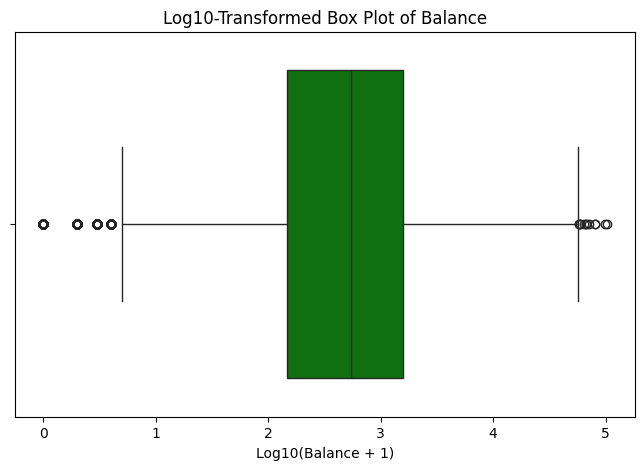

In [ ]:
# ============================================================
# Boxplot with log10 transformation: Balance
# ============================================================
plt.figure(figsize=(8, 5))
sns.boxplot(x=np.log10(df_new['balance'] + 1), color='green')  # add 1 to avoid log(0)
plt.title('Log10-Transformed Box Plot of Balance')
plt.xlabel('Log10(Balance + 1)')
plt.show()


**Observation:** Most balances cluster at low to moderate levels, with a long right tail of high-value outliers even after log transformation.

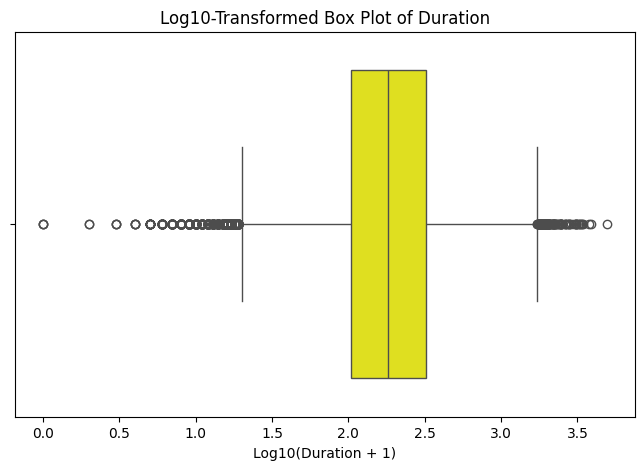

In [ ]:
# ============================================================
# Boxplot with log10 transformation: Duration
# ============================================================
plt.figure(figsize=(8, 5))
sns.boxplot(x=np.log10(df_new['duration'] + 1), color='yellow')  # add 1 to avoid log(0)
plt.title('Log10-Transformed Box Plot of Duration')
plt.xlabel('Log10(Duration + 1)')
plt.show()

**Observation:** Most call durations are short to moderate, with a few unusually long calls forming a right-skewed tail even after log transformation.


<font color = "#FF3B30"> **Outliers in numeric features have been detected and analysed; these insights will help inform preprocessing and model training. Next, we visualise the data to explore relationships between features and the target variable.** </font>


---

**Before starting Exploratory Data Analysis, binary features (default, housing, loan) and the target variable y have been encoded to 0/1. This ensures that correlation and other numeric analyses include the target variable and are compatible with ML modeling.**

In [ ]:
# ============================================================
#  Turn no and yes to 0 and 1
# ============================================================
label_encoder = LabelEncoder()

df_new['default'] = label_encoder.fit_transform(df_new['default'])
df_new['housing'] = label_encoder.fit_transform(df_new['housing'])
df_new['loan'] = label_encoder.fit_transform(df_new['loan'])
df_new['y'] = label_encoder.fit_transform(df_new['y'])

df_new_small['default'] = label_encoder.fit_transform(df_new_small['default'])
df_new_small['housing'] = label_encoder.fit_transform(df_new_small['housing'])
df_new_small['loan'] = label_encoder.fit_transform(df_new_small['loan'])
df_new_small['y'] = label_encoder.fit_transform(df_new_small['y'])


---

1. Numerical Feature Distribution (using histogram and countplot)

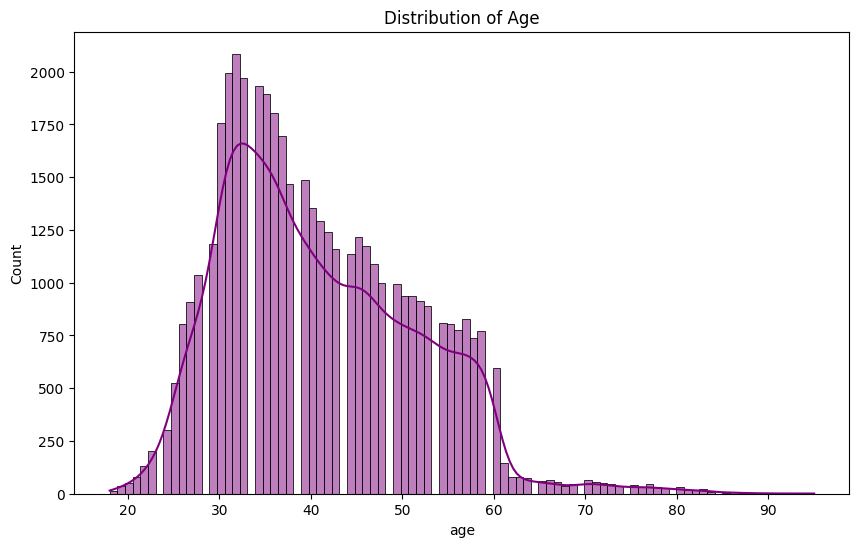

In [ ]:
# ============================================================
# Visualisation of age distribution
# ============================================================

plt.figure(figsize=(10,6))
sns.histplot(df_new['age'], kde=True, color='purple')
plt.title('Distribution of Age')
plt.show()

**Observation:** The majority of clients are between 30 and 50 years old, with very few younger (<20) or older (>70) clients.

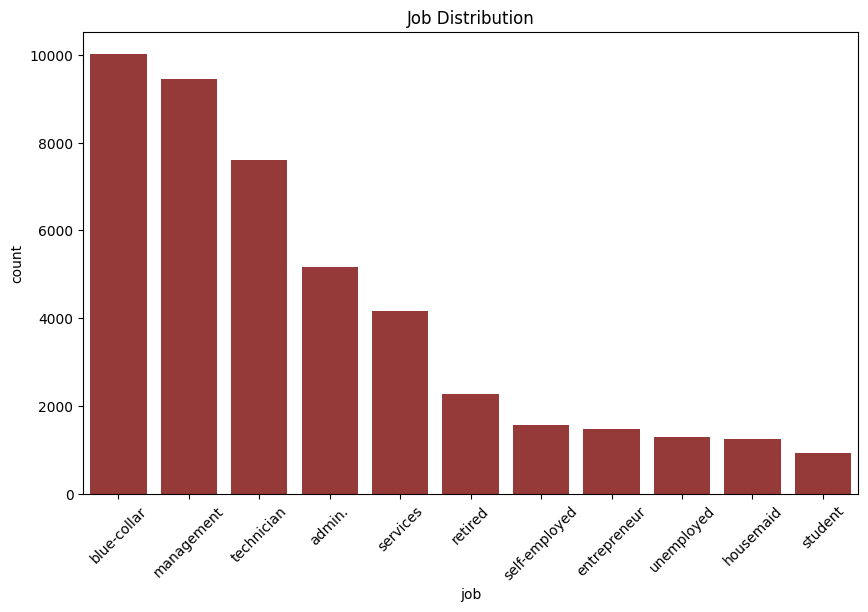

In [ ]:
# ============================================================
# Visualisation of job distribution
# ============================================================

plt.figure(figsize=(10,6))
sns.countplot(data=df_new, x='job', order=df['job'].value_counts().index, color='brown')
plt.title('Job Distribution')
plt.xticks(rotation=45)
plt.show()

**Observation:** Most clients belong to blue-collar, management, and technician categories, while student and unemployed are least represented.

---

2. Correlation heatmap to explore relationships between all features.

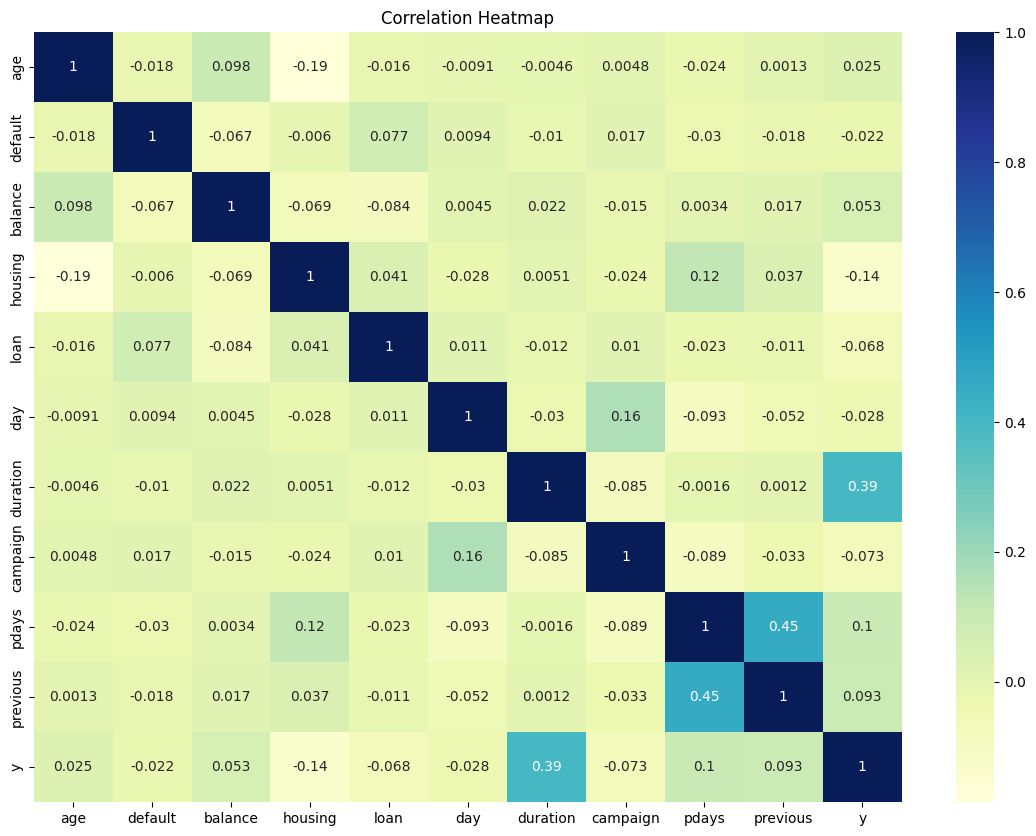

In [ ]:
# ============================================================
# Visualization corrolation
# ============================================================

plt.figure(figsize=(14,10))
sns.heatmap(df_new.corr(numeric_only=True), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()

* Duration (0.39): Longer call durations slightly increase the likelihood of subscription.

* Pdays & Previous (0.45): Clients contacted previously are more likely to subscribe.

* Month & Housing (0.27): These features together show a mild positive correlation with subscription, suggesting that certain months and having a housing loan slightly increase the likelihood of a client subscribing.



---

3. Visualising the relationship between client features job and loan status to understand how loans might influence term deposit subscriptions.

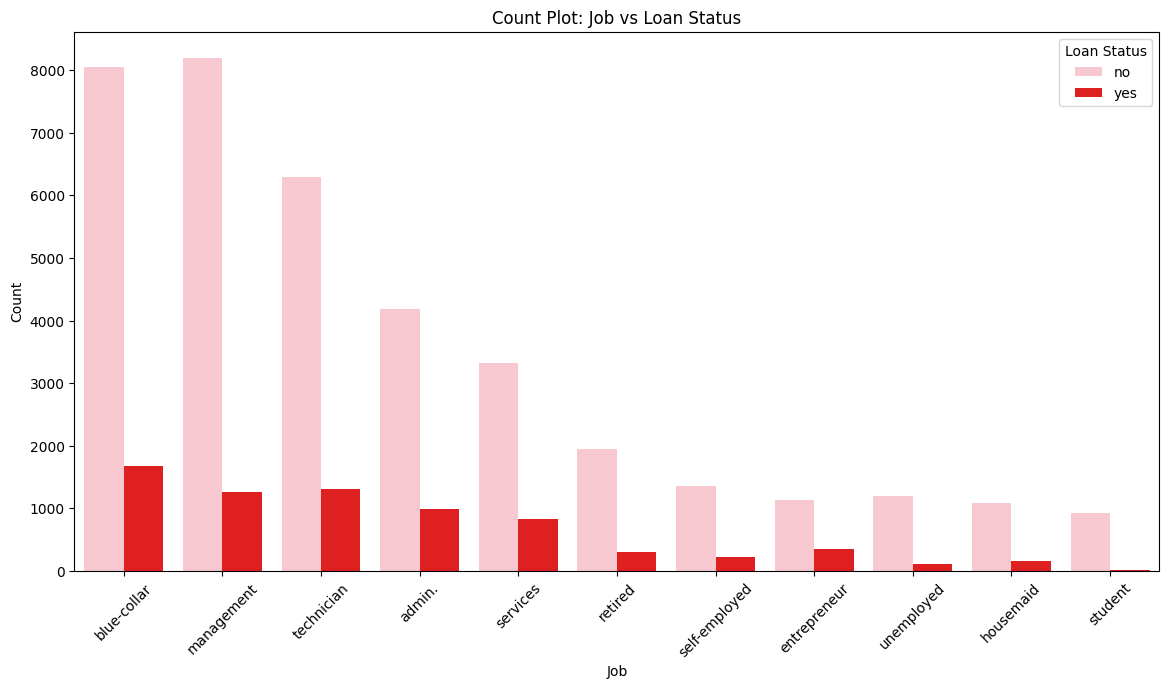

In [ ]:
# ============================================================
# Visualisation age to loan status distribution
# ============================================================

plt.figure(figsize=(14, 7))
sns.countplot(
    data=df,
    x='job',
    hue='loan',
    palette=['pink', 'red'],
    order=df['job'].value_counts().index
)

plt.title('Count Plot: Job vs Loan Status')
plt.xlabel('Job')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Loan Status', loc='upper right')

plt.show()


**Observation:** The distribution shows that personal loans are relatively rare across all job categories. The dataset is dominated by blue-collar, management, and technician roles, meaning these groups contribute the most to loan-related patterns.

---

4. Visualising the relationship between client features age and loan status to understand how loans might influence term deposit subscriptions.

<font color = "#FF3B30"> We used a KDE plot because age is a continuous variable, and KDE provides a smooth curve showing how the two loan-status groups are distributed across different ages. Countplot is not suitable here because it is meant for categorical values, and age has too many unique values. </font>

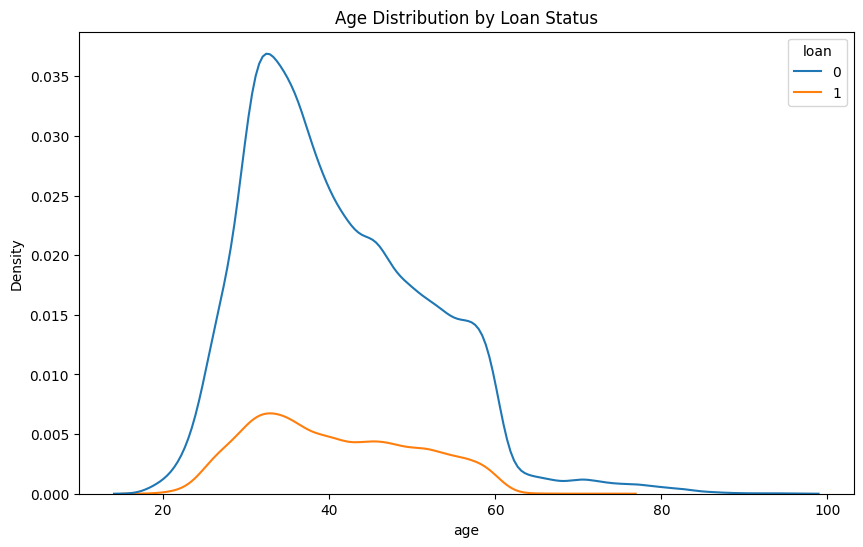

In [ ]:
# ============================================================
# Visualisation age to loan status distribution
# ============================================================

plt.figure(figsize=(10,6))
sns.kdeplot(data=df_new, x='age', hue='loan')
plt.title("Age Distribution by Loan Status")


# Show the plot
plt.show()

**Observation:**
1. Most clients are between 20-40 years old, and within this range, people without
loans (0) are far more common than those with loans (1).
2. Loan holders become extremely rare after age 80, indicating older clients are much less likely to have active loans.

---

5. Visualising the relationship between client features martial status/education to loan status to understand how loans might influence term deposit subscriptions.

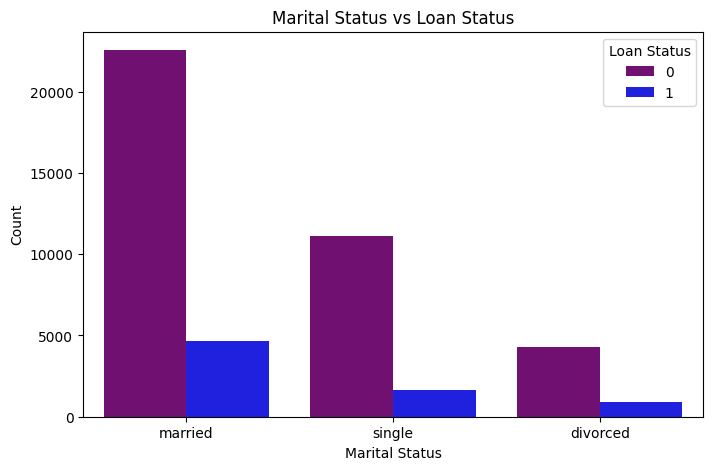

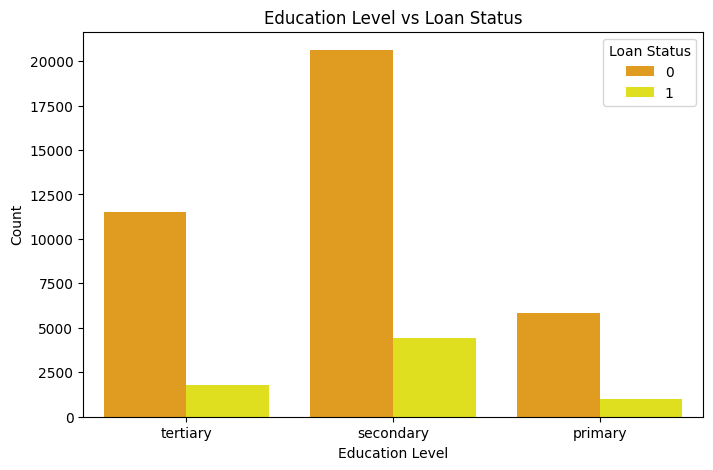

In [ ]:
# ============================================================
# Visualisation marital status/education to loan status distribution
# ============================================================

plt.figure(figsize=(8, 5))
sns.countplot(data=df_new, x='marital', hue='loan', palette=['purple', 'blue'])

# Customize the plot
plt.title('Marital Status vs Loan Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Loan Status', loc='upper right')

plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df_new, x='education', hue='loan', palette=['orange', 'yellow'])

# Customize the plot
plt.title('Education Level vs Loan Status')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Loan Status', loc='upper right')

plt.show()

**Observation:**
1. **Marital Status vs Loan Status:** Married clients dominate the dataset, showing the highest counts for both loan = 0 and loan = 1 compared to single and divorced clients.
2. **Education vs Loan Status:** Clients with secondary education form the largest group, having the highest counts for both loan = 0 and loan = 1 compared to all other education levels.

---

6. Visualising the relationship between client age and call duration to explore patterns that might affect term deposit subscription.

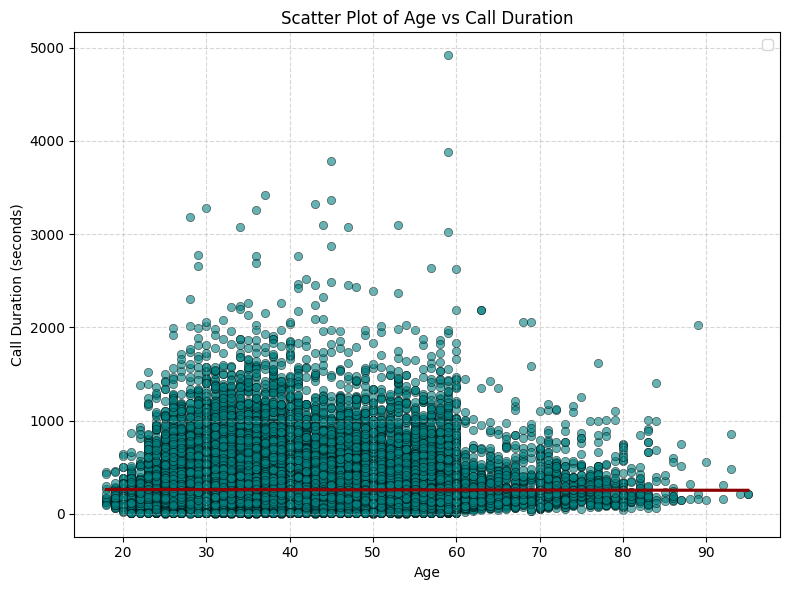

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_new, x='age', y='duration', color='teal', edgecolor='black', alpha=0.6)
sns.regplot(data=df_new, x='age', y='duration', scatter=False, color='darkred', line_kws={'label':"Linear Fit"})

plt.title('Scatter Plot of Age vs Call Duration')
plt.xlabel('Age')
plt.ylabel('Call Duration (seconds)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** The plot shows that most calls last under 1000 seconds across all age groups, with no strong linear relationship. However, a few outliers with very long durations may indicate highly engaged customers who could be more likely to subscribe.

# **<font color ="green"> Encoding Features for Machine Learning </font>** (Dan/Kerim)

1. We encoded the categorical features into numeric values and then separated the dataset into features (X) and target (y), preparing both the full dataset and the 10% sample dataset for model training.


In [ ]:
# ============================================================
#  DEFINE FEATURES AND TARGET and encode remaining values
# ============================================================

# Encode for full dataset
df_new['job'] = label_encoder.fit_transform(df_new['job'])
df_new['marital'] = label_encoder.fit_transform(df_new['marital'])
df_new['education'] = label_encoder.fit_transform(df_new['education'])
df_new['contact'] = label_encoder.fit_transform(df_new['contact'])
df_new['month'] = label_encoder.fit_transform(df_new['month'])

# Encode for 10% dataset
df_new_small['job'] = label_encoder.fit_transform(df_new_small['job'])
df_new_small['marital'] = label_encoder.fit_transform(df_new_small['marital'])
df_new_small['education'] = label_encoder.fit_transform(df_new_small['education'])
df_new_small['contact'] = label_encoder.fit_transform(df_new_small['contact'])
df_new_small['month'] = label_encoder.fit_transform(df_new_small['month'])

# Define features and target
X = df_new.drop('y', axis=1)
y = df_new['y']

X_small = df_new_small.drop('y', axis=1)
y_small = df_new_small['y']


2. We separated the dataset into categorical and numeric features to handle them appropriately during preprocessing and modeling.

In [ ]:
# Identify categorical and numeric columns
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']
numeric_features = [c for c in X.columns if c not in categorical_features]

3. We used df.info() to verify that all categorical features were properly encoded to numeric values and the dataset is ready for modeling.

In [ ]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  int64
 2   marital    45211 non-null  int64
 3   education  45211 non-null  int64
 4   default    45211 non-null  int64
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  int64
 7   loan       45211 non-null  int64
 8   contact    45211 non-null  int64
 9   day        45211 non-null  int64
 10  month      45211 non-null  int64
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  y          45211 non-null  int64
dtypes: int64(16)
memory usage: 5.5 MB


---

# **<font color = "green"> Analysing Features Before Model Training (Simran / Snehdeep) </font>**

1. Target Class Imbalance (y): Check the imbalance to understand the dataset, then choose the right method (like SMOTE or class weighting) so the model can learn both classes properly and make reliable predictions.

In [ ]:
df['y'].value_counts()
df['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


**Observation:** The dataset is highly imbalanced, with 88.3% “no” and only 11.7% “yes,” so we need to handle this before training a model to ensure it can learn both classes effectively.

**Imbalance strategy:** •	The best strategy to use would be oversampling and using the SMOTE technique to add synthetic rows to the dataset that are like the rows for the existing minority class. This is better than adding duplicates of the rows for the minority class which can lead to overfitting. This will be the better strategy to use because undersampling will remove rows from the dataset, potentially losing valuable information that the model needs to learn the true underlying patterns of the dataset.

---

2. Categorical Feature Imbalance: Check the percentage of each category in categorical features to understand their distribution and identify rare categories before modeling.



In [ ]:
cat_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month']

for col in cat_features:
    print(f"Feature: {col}")
    print(df_new[col].value_counts(normalize=True) * 100)
    print("-" * 50)

Feature: job
job
1     22.162748
4     20.919688
9     16.803433
0     11.437482
7      9.188029
5      5.007631
6      3.492513
2      3.289023
10     2.882042
3      2.742695
8      2.074716
Name: proportion, dtype: float64
--------------------------------------------------
Feature: marital
marital
1    60.193316
2    28.289576
0    11.517109
Name: proportion, dtype: float64
--------------------------------------------------
Feature: education
education
1    55.426777
2    29.419831
0    15.153392
Name: proportion, dtype: float64
--------------------------------------------------
Feature: default
default
0    98.197341
1     1.802659
Name: proportion, dtype: float64
--------------------------------------------------
Feature: housing
housing
1    55.583818
0    44.416182
Name: proportion, dtype: float64
--------------------------------------------------
Feature: loan
loan
0    83.977351
1    16.022649
Name: proportion, dtype: float64
--------------------------------------------------


**Observation:**
1. Some categories are very rare (like default = 1, month = dec), which might affect model learning.

2. Features like job, marital, and education are well distributed, so models can learn patterns effectively.

3. Knowing these distributions helps us decide encoding strategies and handle rare categories if needed.

---

# **<font color ="green"> Training and Testing </font>**

<font color ="purple"> Train-Test Split </font>

1. Split the dataset into training, validation, and testing sets, keeping the class balance.

In [ ]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

#Full Dataset
X_train_original, X_test, y_train_original, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#10% Dataset
X_train, X_validation, y_train, y_validation = train_test_split(
    X_train_original, y_train_original, test_size=0.25, stratify=y_train_original, random_state=42
)

---

<font color = "purple"> Baseline Model </font>

**1. Logistic Regression**

In [ ]:
# ===================================================================================
# LOGISTIC REGRESSION MODEL BEFORE (SMOTE, OHE, ROBUST SCALER, AND HANDLING OUTLIERS)
# ===================================================================================

log_raw = LogisticRegression(max_iter=20000, random_state=42)
log_raw.fit(X_train, y_train)

y_pred_log_raw = log_raw.predict(X_test)

print("=== LOGISTIC REGRESSION — RAW MODEL ===")
print(classification_report(y_test, y_pred_log_raw))

=== LOGISTIC REGRESSION — RAW MODEL ===
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      7985
           1       0.59      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043



**Observation (Logistic Regression):**  89% accuracy; predicts ‘No’ very well (recall 0.98) but struggles with ‘Yes’ (recall 0.22, F1-score 0.32).

---

**2. Random Forest** (Daniel Roberts)

In [ ]:
# ===================================================================================
# RANDOM FOREST MODEL BEFORE (SMOTE, OHE, ROBUST SCALER, AND HANDLING OUTLIERS)
# ===================================================================================

from sklearn.ensemble import RandomForestClassifier

rf_raw = RandomForestClassifier(random_state=42)
rf_raw.fit(X_train, y_train)

y_pred_raw = rf_raw.predict(X_test)

print("RANDOM FOREST === RAW MODEL ===")
print(classification_report(y_test, y_pred_raw))

RANDOM FOREST === RAW MODEL ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.60      0.35      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.90      0.88      9043



**Observation(Random Forest):** 90% accuracy; better than logistic regression on ‘Yes’ (recall 0.33, F1-score 0.43), while still predicting ‘No’ accurately (recall 0.97)

<font color = "purple"> Handle Outliers </font> (Daniel Roberts)

2. Handle outliers in numeric features by keeping values between the 1st and 99th percentiles in training, validation, and test sets so that extreme numbers don’t affect the model too much.


In [ ]:
# -------------------------------
# Handle outliers in numeric features
# Using 1st and 99th percentile clipping
# -------------------------------
for col in numeric_features:
    lower = X_train[col].quantile(0.01)
    upper = X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(lower, upper)
    X_validation[col] = X_validation[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)

X_small_clipped = X_small.copy()

for col in numeric_features:
    lower = X_small[col].quantile(0.01)
    upper = X_small[col].quantile(0.99)
    X_small_clipped[col] = X_small[col].clip(lower, upper)

<font color = "purple"> Handling Class Imbalance with SMOTENC </font> (Daniel Roberts)

Applied SMOTENC on the training set to balance the target classes because the dataset is highly imbalanced (88% “no” vs 12% “yes”), ensuring the model can learn both classes effectively.

In [ ]:
from imblearn.over_sampling import SMOTENC

# ===== Apply SMOTENC on training set =====
categorical_cols = ['job','marital','education','housing','loan']
cat_indices = [X_train.columns.get_loc(c) for c in categorical_cols]

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_res, y_train_res = smote_nc.fit_resample(X_train, y_train)

print("Original target distribution:\n", y_train.value_counts(normalize=True) * 100)
print("\nResampled target distribution:\n", y_train_res.value_counts(normalize=True) * 100)

# ===== Apply SMOTENC on small dataset =====
smote_nc_small = SMOTENC(categorical_features=[X_small_clipped.columns.get_loc(c) for c in categorical_cols], random_state=42)
X_small_res, y_small_res = smote_nc_small.fit_resample(X_small_clipped, y_small)

#check distributions
print("Original target distribution (small dataset):\n", y_small.value_counts(normalize=True) * 100)
print("\nResampled target distribution (small dataset):\n", y_small_res.value_counts(normalize=True) * 100)


Original target distribution:
 y
0    88.302735
1    11.697265
Name: proportion, dtype: float64

Resampled target distribution:
 y
0    50.0
1    50.0
Name: proportion, dtype: float64
Original target distribution (small dataset):
 y
0    88.476001
1    11.523999
Name: proportion, dtype: float64

Resampled target distribution (small dataset):
 y
0    50.0
1    50.0
Name: proportion, dtype: float64


**Result:** After applying SMOTENC, both the full and small datasets have balanced target classes, changing from ~88% “no” / 12% “yes” to 50% each.


---

## **<font color = "green"> Training Models </font>**

## **<font color = "orange"> 1. Logistic Regression (Baseline Model)</font>** - (Daniel Roberts/Kerim/Snehdeep Kaur/Simran.D)


***Preprocessing Steps***

i. One-Hot Encoding of Categorical Features

One-hot encoded categorical features after SMOTENC to convert them into binary columns suitable for Logistic Regression, ensuring each category is treated equally without implying any order.



In [ ]:
from sklearn.preprocessing import OneHotEncoder

# ===== One-hot encode categorical features (after SMOTENC) =====
ohe_cols = ['job','marital','education','contact','month']  # only these
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train_res[ohe_cols])

X_train_ohe = ohe.transform(X_train_res[ohe_cols])
X_val_ohe = ohe.transform(X_validation[ohe_cols])
X_test_ohe = ohe.transform(X_test[ohe_cols])

# ===== One-hot encode categorical features (after SMOTENC) for small dataset =====
ohe_small = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
ohe_small.fit(X_small_res[ohe_cols])  # fit on resampled small dataset

X_small_ohe = ohe_small.transform(X_small_res[ohe_cols])  # transform resampled small dataset

---

Scaled numeric features using RobustScaler to bring them to a similar range and reduce the impact of outliers, making the data suitable for Logistic Regression.

In [ ]:
# -------------------------------
# Scale numeric features using RobustScaler
# -------------------------------
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(X_train_res[numeric_features])

X_train_num = scaler.transform(X_train_res[numeric_features])
X_val_num = scaler.transform(X_validation[numeric_features])
X_test_num = scaler.transform(X_test[numeric_features])

# ===== Scale numeric features for small dataset =====
scaler_small = RobustScaler()
scaler_small.fit(X_small_res[numeric_features])

# Transform numeric features
X_small_num = scaler_small.transform(X_small_res[numeric_features])

---

Merge the scaled numeric features and one-hot encoded categorical features into the final dataset ready for model training.

In [ ]:
# -------------------------------
# Combine numeric and encoded categorical features
# -------------------------------
X_train_final = np.hstack([X_train_num, X_train_ohe])
X_val_final = np.hstack([X_val_num, X_val_ohe])
X_test_final = np.hstack([X_test_num, X_test_ohe])

X_small_final = np.hstack([X_small_num, X_small_ohe])

---

***Model tuning***

Performed **GridSearchCV** to find the best hyperparameters (`C` and `class_weight`) for Logistic Regression, optimising F1-score to improve predictions for both “yes” and “no” classes.


In [ ]:
from sklearn.model_selection import GridSearchCV

# ============================================================
# HYPERPARAMETER GRIDSearchCV
# ============================================================
param_grid = {
    "C": [0.01, 0.1, 1, 5, 10],
    "class_weight": [{0:1, 1:w} for w in [1,2,3,4,5,6]]
}

log_reg = LogisticRegression(max_iter=20000)

grid = GridSearchCV(
    log_reg,
    param_grid,
    scoring="f1",      # scoring during CV
    cv=5,
    n_jobs=-1
)

# Fit only on the RESAMPLED TRAINING DATA
grid.fit(X_train_final, y_train_res)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameters: {'C': 0.01, 'class_weight': {0: 1, 1: 2}}
Best CV F1: 0.8295036943314171


***Training***

Trained the final Logistic Regression model on the resampled and preprocessed training set using the best hyperparameters from GridSearchCV.

In [ ]:
# ===============================================================================
# TRAIN NEW LOGISTIC REGRESSION MODEL ON BEST PARAMETERS AND FIT ON TRAINING SET
# ===============================================================================

best_params = grid.best_params_

final_model = LogisticRegression(
    max_iter=20000,
    **best_params
)

final_model.fit(X_train_final, y_train_res)

LogisticRegression(C=0.01, class_weight={0: 1, 1: 2}, max_iter=20000)

In [ ]:
# ============================================================
# THRESHOLD TUNING ON VALIDATION SET
# ============================================================
y_val_probs = final_model.predict_proba(X_val_final)[:, 1]

results = []

thresholds = np.arange(0.05, 0.95, 0.01)

for t in thresholds:
    y_pred = (y_val_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_validation, y_pred).ravel()

    precision = precision_score(y_validation, y_pred, zero_division=0)
    recall = recall_score(y_validation, y_pred, zero_division=0)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Keep thresholds where both conditions are satisfied
    if tp > fp and fn < fp:
        results.append({
            "threshold": t,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

if len(results) == 0:
    print("No threshold found satisfying both TP > FP and FN < FP.")
    # Fallback: select threshold where TP > FP only
    fallback_results = []
    for t in thresholds:
        y_pred = (y_val_probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_validation, y_pred).ravel()
        precision = precision_score(y_validation, y_pred, zero_division=0)
        recall = recall_score(y_validation, y_pred, zero_division=0)
        if tp > fp:
            fallback_results.append({
                "threshold": t,
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "precision": precision,
                "recall": recall
            })
    if len(fallback_results) > 0:
        best = max(fallback_results, key=lambda x: x["recall"])
        print("\n====== FALLBACK THRESHOLD (TP > FP) ======")
        print(f"Threshold: {best['threshold']:.2f}")
        print(f"TP: {best['tp']}, FP: {best['fp']}, FN: {best['fn']}")
        print(f"Precision: {best['precision']:.3f}, Recall: {best['recall']:.3f}")
        print("================================\n")
    else:
        print("No threshold satisfies TP > FP either.")
else:
    # Select the threshold with highest F1 among valid thresholds
    best = max(results, key=lambda x: x["f1"])

    print("\n====== SELECTED THRESHOLD ======")
    print(f"Threshold: {best['threshold']:.2f}")
    print(f"TP: {best['tp']}, FP: {best['fp']}, FN: {best['fn']}")
    print(f"Precision: {best['precision']:.3f}, Recall: {best['recall']:.3f}, F1: {best['f1']:.3f}")
    print("================================\n")


No threshold found satisfying both TP > FP and FN < FP.

====== FALLBACK THRESHOLD (TP > FP) ======
Threshold: 0.89
TP: 420, FP: 406, FN: 638
Precision: 0.508, Recall: 0.397



# **<font color = "green"> Evaluation (Logistic Regression)**

In [ ]:
# ============================================================
# EVALUATE FINAL MODEL ON TEST SET
# ============================================================
# Use best threshold on test set
y_test_probs = final_model.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_probs >= best["threshold"]).astype(int)

print("Test set report using best threshold:")
print(classification_report(y_test, y_test_pred))
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
print(f"Confusion matrix:\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

Test set report using best threshold:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      7985
           1       0.50      0.39      0.44      1058

    accuracy                           0.88      9043
   macro avg       0.71      0.67      0.69      9043
weighted avg       0.87      0.88      0.88      9043

Confusion matrix:
TP: 412, TN: 7568, FP: 417, FN: 646


Using the optimised threshold on the test set, the model achieved 88% accuracy, correctly predicting most ‘No’ cases but still struggling with ‘Yes’ cases , resulting in moderate precision (0.50) and low recall (0.40) for the positive class.

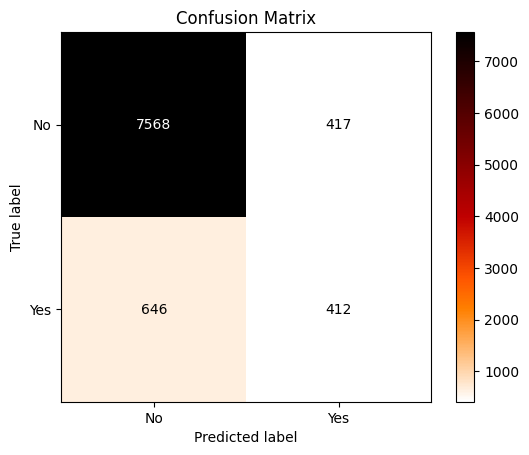

In [ ]:
# ============================================================
#CONFUSION MATRIX GRAPH
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
disp.plot(cmap='gist_heat_r')
plt.title('Confusion Matrix')
plt.show()

**Key points:**

1. The model predicts “No” very well (TN: 7568) but misses many actual “Yes” cases (TP: 412 vs FN: 646).

2. False positives are relatively low (FP: 417), so it rarely mislabels “No” as “Yes.”

**<font color = "#FF3B30"> Conclusion:
Despite applying multiple techniques, logistic regression still struggles with positive class prediction, showing it is not the best model for this dataset. </font>**

# **More Models**

## **<font color = "orange"> 2. Random Forest Classifier</font>** - (Daniel Roberts)

In [ ]:
# =============================================================================================================================
# RANDOM FOREST MODEL AFTER (SMOTE, OHE, ROBUST SCALER, AND HANDLING OUTLIERS) BUT BEFORE (HYPERPARAMETER AND THRESHOLD TUNING)
# =============================================================================================================================

rf_preprocessed = RandomForestClassifier(random_state=42)
rf_preprocessed.fit(X_train_final, y_train_res)

y_pred_preprocessed = rf_preprocessed.predict(X_test_final)

print("=== PREPROCESSED MODEL ===")
print(classification_report(y_test, y_pred_preprocessed))

=== PREPROCESSED MODEL ===
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      7985
           1       0.46      0.71      0.55      1058

    accuracy                           0.87      9043
   macro avg       0.71      0.80      0.74      9043
weighted avg       0.90      0.87      0.88      9043



We tuned the Random Forest hyperparameters using RandomizedSearchCV with 3-fold cross-validation, optimizing F1-score to better balance precision and recall for the positive class. (Snehdeep)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define smaller parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Create Random Forest model
rf = RandomForestClassifier(random_state=42)

# Randomized search with 20 random combinations
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,          # number of random combinations
    scoring='f1',       # optimize F1-score
    cv=3,               # 3-fold CV to save time
    n_jobs=-1,          # use all CPUs
    verbose=2,
    random_state=42
)

# Fit on small dataset
random_search.fit(X_small_final, y_small_res)

# Get best model and parameters
best_rf = random_search.best_estimator_
print("Best parameters:", random_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [ ]:
print("Best hyperparameters found on small dataset:")
print(random_search.best_estimator_)  # shows the best Random Forest model

Best hyperparameters found on small dataset:
RandomForestClassifier(random_state=42)


In [ ]:
# Show best hyperparameter combination
print("Best hyperparameters found:", random_search.best_params_)

Best hyperparameters found: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


<font color ="#FF3B30"> The best parameters found (100 trees, max_depth=None, min_samples_split=2, min_samples_leaf=1) will be used to train the final model on the full dataset. </font>

In [ ]:
print("Best F1-score on small dataset:", random_search.best_score_)

Best F1-score on small dataset: 0.901112800474296


Random Forest tuned on a small dataset achieved a best F1-score of 0.90

---

***Training***

We first tuned the Random Forest on a small subset to quickly find the best hyperparameters. Then, we trained the final model on the full dataset to maximise learning and improve overall performance

In [ ]:
# -------------------------------
#Train final model on full dataset with best params
# -------------------------------
best_params = random_search.best_params_

rf_full = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)
rf_full.fit(X_train_final, y_train_res)

RandomForestClassifier(random_state=42)

Similar to logistic regression, we performed threshold tuning for the Random Forest to maximize F1-score. The optimal threshold for logistic regression was 0.89, while for Random Forest it was 0.49, reflecting differences in how each model predicts the positive class.

In [ ]:
# Predict probabilities on validation set
y_val_probs = rf_full.predict_proba(X_val_final)[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
results = []

for t in thresholds:
    y_pred = (y_val_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_validation, y_pred).ravel()
    precision = precision_score(y_validation, y_pred, zero_division=0)
    recall = recall_score(y_validation, y_pred, zero_division=0)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    results.append({"threshold": t, "tp": tp, "fp": fp, "fn": fn,
                    "precision": precision, "recall": recall, "f1": f1})

best = max(results, key=lambda x: x["f1"])  # or choose another metric
best_threshold = best['threshold']
print(f"Selected threshold: {best_threshold:.2f}")

Selected threshold: 0.49


# **<font color = "green"> Evaluation (Random Forest)** - (Daniel Roberts)

In [ ]:
# -------------------------------
#Evaluate on test set
# -------------------------------
y_test_probs = rf_full.predict_proba(X_test_final)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("Final model evaluation on full test set:")
print(classification_report(y_test, y_test_pred))
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
print(f"Confusion matrix:\nTP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

Final model evaluation on full test set:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      7985
           1       0.46      0.72      0.56      1058

    accuracy                           0.87      9043
   macro avg       0.71      0.80      0.74      9043
weighted avg       0.90      0.87      0.88      9043

Confusion matrix:
TP: 764, TN: 7070, FP: 915, FN: 294


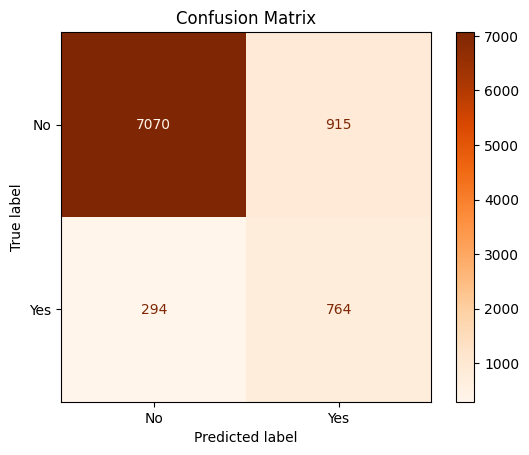

In [ ]:
# ============================================================
#CONFUSION MATRIX GRAPH
# ============================================================

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No','Yes'])
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix')
plt.show()

**<font color = "#FF3B30"> Conclusion:
This shows a massively improved model from the logistic regression model, as although it predicts slightly less for the negative class correctly, it correctly predicts nearly double the amount for the positive class. Also, there is less false negatives than there is false positives, which is desired for the purpose of our model.</font>**

# **<font color = "purple"> Model Comparison(Simran / Snehdeep) </font>**

- **Random Forest:** Accuracy 87%, better at finding people who take loans (higher recall), but more wrong loan predictions (higher FP). Although this is not an accurate measure because the target feature is imbalanced.
- **Logistic Regression:** Fewer wrong loan predictions (higher precision), but misses more real loans (lower recall).  
- **Takeaway:** Use RF if finding all loans is more important.


## **<font color = "orange"> 3. Support Vector Machine (SVM)</font>** (Kerim)

In [ ]:
# ============================================================
# TRAIN SVM MODEL (FASTER VERSION)
# ============================================================

from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Use a pipeline to scale features (important for SVM)
svm_model = make_pipeline(
    StandardScaler(),
    LinearSVC(C=1.0, max_iter=10000, random_state=42)
)

# Train the model
svm_model.fit(X_train_final, y_train_res)

# Evaluate on test set
test_accuracy = svm_model.score(X_test_final, y_test)
print("SVM test accuracy:", test_accuracy)


SVM test accuracy: 0.8198606657082826


We trained a Support Vector Machine using a linear kernel (LinearSVC), scales the features using StandardScaler, and evaluates the model on a test set. The final output shows that the SVM model has an accuracy of ~81.98% on the test data.

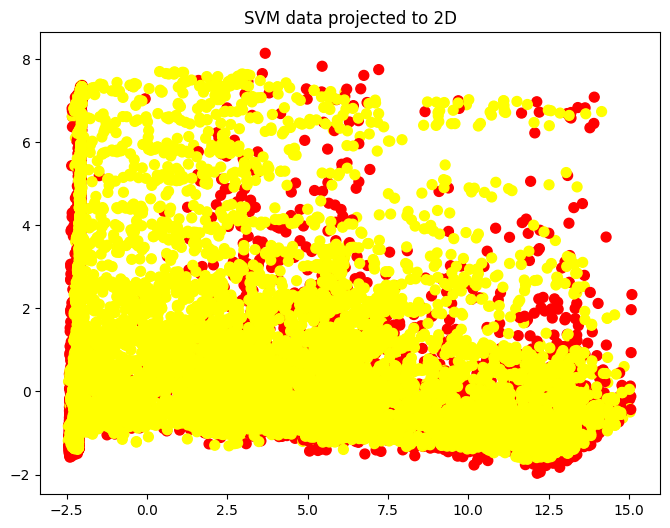

In [ ]:
# ============================================================
# OUTPUT OF SVM MODEL
# ============================================================
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_final)

# Scatter plot of training data in 2D
plt.figure(figsize=(8,6))
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_res, s=50, cmap='autumn')
plt.title("SVM data projected to 2D")
plt.show()

**<font color = "#FF3B30">Conclusion: Based on the output, this model isn't very compatible with the data due to significant overlap, as the data isn't linearly separable. This makes it difficult for the algorithm to find a clear optimal hyperplane. A different model, more suited for classification with non-linear data, would likely perform better in this case.</font>**